In [1]:
import cv2 as cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img1_col = cv2.imread('../2_edges_and_features/images/almanac.jpg')
img1 = cv2.cvtColor(img1_col, cv2.COLOR_BGR2GRAY)
img1_col = cv2.cvtColor(img1_col, cv2.COLOR_BGR2RGB)

img2_col = cv2.imread('../2_edges_and_features/images/desk.jpg')
img2 = cv2.cvtColor(img2_col, cv2.COLOR_BGR2GRAY)
img2_col = cv2.cvtColor(img2_col, cv2.COLOR_BGR2RGB)


In [3]:
sift = cv2.SIFT_create()

In [4]:
keypoints1, descriptors1 = sift.detectAndCompute(img1, None)
keypoints2, descriptors2 = sift.detectAndCompute(img2, None)

In [5]:
bf = cv2.BFMatcher(cv2.NORM_L2)
matches = bf.match(descriptors1, descriptors2)

In [6]:
matches = sorted(matches, key = lambda x:x.distance)[:50]

extract the locations of matched keypoints in both the images

In [7]:
src_pts = np.float32([keypoints1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
dst_pts = np.float32([keypoints2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

In [8]:
src_pts

array([[[249.13246 , 314.8534  ]],

       [[132.39325 , 479.46637 ]],

       [[310.2118  , 438.1864  ]],

       [[258.85074 , 243.62746 ]],

       [[322.61896 , 453.59775 ]],

       [[ 58.005665,  30.893938]],

       [[239.88617 , 295.65424 ]],

       [[ 59.53094 , 378.10385 ]],

       [[ 58.005665,  30.893938]],

       [[182.10802 , 370.79834 ]],

       [[260.9351  , 232.32986 ]],

       [[168.74132 , 525.99426 ]],

       [[368.94016 , 210.99573 ]],

       [[ 79.56495 , 326.4326  ]],

       [[260.9351  , 232.32986 ]],

       [[ 54.356678, 364.86185 ]],

       [[296.1517  , 231.69131 ]],

       [[296.1517  , 231.69131 ]],

       [[329.45914 , 241.60536 ]],

       [[132.39325 , 479.46637 ]],

       [[103.6145  , 253.51326 ]],

       [[ 58.863163, 307.8531  ]],

       [[215.63914 , 509.63876 ]],

       [[331.47086 , 230.64618 ]],

       [[147.51604 , 245.7535  ]],

       [[110.50515 , 518.9902  ]],

       [[ 12.865198, 518.25226 ]],

       [[194.94406 , 463.923

In [9]:
dst_pts

array([[[1189.8048 ,  985.1509 ]],

       [[1059.1482 , 1016.46765]],

       [[1170.016  , 1067.8458 ]],

       [[1225.176  ,  955.2665 ]],

       [[1170.0183 , 1079.6346 ]],

       [[1204.7816 ,  790.7735 ]],

       [[1193.2627 ,  972.13385]],

       [[1065.5387 ,  942.1366 ]],

       [[1204.7816 ,  790.7735 ]],

       [[1130.3528 ,  984.98926]],

       [[1231.0029 ,  950.9355 ]],

       [[1057.3352 , 1052.4957 ]],

       [[1222.0665 , 1260.5271 ]],

       [[1096.8276 ,  925.9879 ]],

       [[1231.0029 ,  950.9355 ]],

       [[1068.4103 ,  934.18677]],

       [[1231.0029 ,  950.9355 ]],

       [[1231.0029 ,  950.9355 ]],

       [[1225.176  ,  955.2665 ]],

       [[1059.1482 , 1016.46765]],

       [[1138.8385 ,  902.2226 ]],

       [[1094.0964 ,  910.4355 ]],

       [[1089.2489 , 1063.3337 ]],

       [[1170.2157 ,  910.10486]],

       [[1164.6277 ,  914.1192 ]],

       [[1481.9148 ,  387.23163]],

       [[1222.0665 , 1260.5271 ]],

       [[ 997.0728 , 1250.32

find the perspective transformation (3x3 transformation matrix)

In [10]:
M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

In [11]:
M

array([[ 2.68106262e-01, -4.90089763e-01,  1.18782508e+03],
       [ 1.66959786e-01,  3.48738506e-01,  7.59017610e+02],
       [-1.93968287e-04, -8.55616824e-05,  1.00000000e+00]])

mask for inliers

In [12]:
matchesMask = mask.ravel().tolist()

transform the corners of queryImage to corresponding points in trainImage

In [13]:
h, w = img1.shape
query_corners = np.float32([[0, 0], [0, h-1], [w-1, h-1],[w-1, 0]]).reshape(-1, 1, 2)
transformed_points = cv2.perspectiveTransform(query_corners, M)

In [14]:
transformed_points

array([[[1187.8251 ,  759.01764]],

       [[ 940.84247, 1022.0376 ]],

       [[1139.9548 , 1183.4144 ]],

       [[1395.8218 ,  890.10803]]], dtype=float32)

show outline of transformed object in green

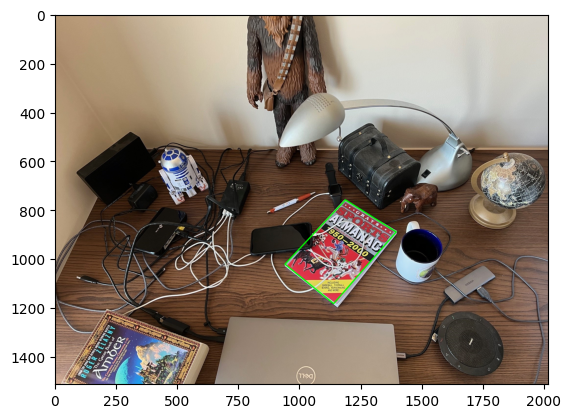

In [15]:
img2_col = cv2.polylines(img2_col, [np.int32(transformed_points)], True, (0, 255, 0), 3, cv2.LINE_AA)
plt.imshow(img2_col)

show together with inlier matches

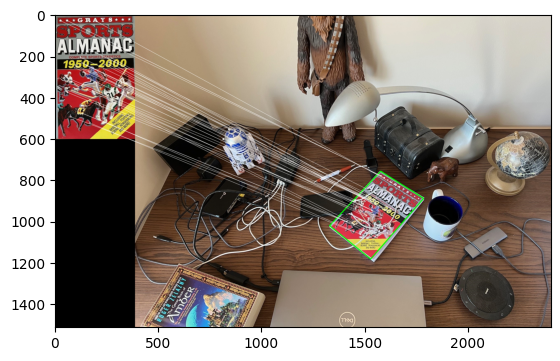

In [16]:
draw_params = dict(matchColor = (255, 255, 255), singlePointColor = None, matchesMask = matchesMask, flags = 2)
image_perspective = cv2.drawMatches(img1_col, keypoints1, img2_col, keypoints2, matches, None, **draw_params)
plt.imshow(image_perspective)

apply homography to full image

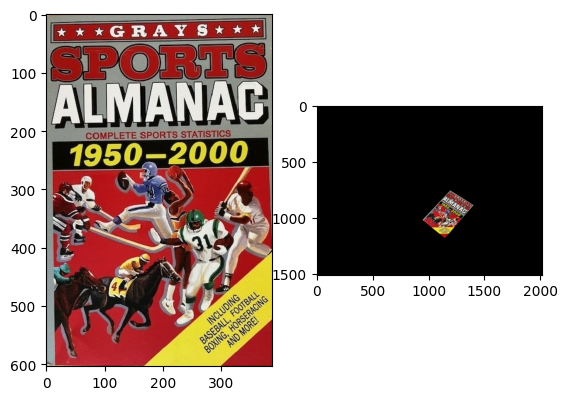

In [17]:
h, w = img2.shape
warped_image = cv2.warpPerspective(img1_col, M, (w, h))

plt.subplot(121)
plt.imshow(img1_col)
plt.subplot(122)
plt.imshow(warped_image)